# Hamiltonian learning from Matrix Product States (MPS)

## Imports

Similarly to the notebook of activity 3, we have separated the main functions to separate scripts, in order to keep the code here simple. We have left the functions that are more unique to the task.

In [1]:
import numpy as np
import torch
from torchvision import transforms, datasets
import tensorkrowch as tk

import jax
import jax.numpy as jnp

import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import glob
import yaml
import matplotlib.pyplot as plt
import torchtt as tntt 

import os
import sys

sys.path.append('../src/')

from utils import check_for_nans, print_model_parameters
from plots import bar_plot_strings_comparison, plot_training_loss
from NeuralNetworks import MPOLinearTorchTT, NeuralNetworkTrainableMPO, NeuralNetworkMPO, SimpleMPONetwork, TrainableMPOLayer, MPS_MLP
from physics import paulis, kron_n, rk4_step, build_hamiltonian, schrodinger_rhs, evolve_state, time_evolution, physics_computation
from physics import prepare_initial_state, OperatorClass



In [2]:
def load_config(config_path):
    '''Load configuration from YAML file'''
    with open(config_path, 'r') as file:
        config = yaml.safe_load(file)
    return config

def load_experimental_data(config):
    """Load experimental/simulated data"""
    N = config["L"]
    chi = config['bond_dimension_data']
    T_max = config["t_max"]
    kind = config['data_kind'] 
    if kind == 'mps':
        search_pattern = f"../data/experimental_data_quantum_sampling_L{N}_Chi_{chi}_*_counts.csv"
    else:
        search_pattern = f"../data/experimental_data_quantum_sampling_L{N}_{kind}_*_counts.csv"

    files = glob.glob(search_pattern)

    if not files:
        raise FileNotFoundError(f"No data found for L={N}")

    config_file = files[0]
    file_core = config_file.replace(".csv", "").replace("../data/experimental_data_quantum_sampling_", "")
    
    print(f"\n{'='*60}")
    print(f"LOADING DATA: {file_core}")
    print(f"{'='*60}")
    
    df_counts = pd.read_csv(f"../data/experimental_data_quantum_sampling_{file_core}.csv")
        
    # Remove leading single quote if present
    if df_counts['bitstring'].astype(str).str.startswith("'").all():
        df_counts['bitstring'] = df_counts['bitstring'].str[1:]
    
    # Now extract values
    bitstrings = df_counts['bitstring'].values.astype(str)
    counts_shots = df_counts['count'].values.astype(np.int32)
    
    return bitstrings, counts_shots

def load_and_convert_to_mpo(model_path, config):
    """
    Load a trained dense model and convert it to MPO format.
    
    Args:
        model_path: Path to saved dense model
        config: Configuration dictionary
        compression_rank: Bond dimension for MPO compression (if None, uses config value)
    """
    
    print("\n" + "="*60)
    print("PHASE 2: LOADING AND CONVERTING TO MPO")
    print("="*60)
    
    # Load the saved dense model
    checkpoint = torch.load(model_path)
    print(f"Loaded model from: {model_path}")
    

    compression_rank = config.get('MAX_MPO_CHI', 2)
    
    # Create MPO model (use_mpo=True)
    mpo_model = NeuralNetworkMPO(
        L=config['L'],
        mpo_size=config['MPO_SIZE'],
        output_dim=checkpoint['final_params']['theta'].shape[0],  # Get from saved params
        max_bond_dim=compression_rank,
        use_mpo=True  #Use MPO for inference
    )
    
    # First, load the embedding, hidden, and output layers from dense model
    dense_state_dict = checkpoint['model_state_dict']
    
    # Filter state dict to only load non-MPO layers first
    mpo_state_dict = mpo_model.state_dict()
    
    # Copy weights for all layers except fc_mpo (we'll handle separately)
    for name, param in dense_state_dict.items():
        if name in mpo_state_dict and 'fc_mpo' not in name:
            mpo_state_dict[name].copy_(param)
            print(f"  Loaded: {name}")
    
    # Load the partially filled state dict
    mpo_model.load_state_dict(mpo_state_dict, strict=False)
    
    # Now handle the MPO layer specially
    print("\n🔄 Converting dense fc_mpo layer to MPO format...")
    
    # Extract the trained dense weights for fc_mpo
    dense_fc_mpo_weight = dense_state_dict['fc_mpo.weight']
    dense_fc_mpo_bias = dense_state_dict['fc_mpo.bias']
    
    # Use our custom method to load dense weights into MPO format
    mpo_model.load_dense_weights(dense_fc_mpo_weight, dense_fc_mpo_bias)
    
    print(f"✅ MPO conversion complete with bond dimension = {compression_rank}")
    print(f"   Original dense weights: {dense_fc_mpo_weight.shape}")
    print(f"   MPO cores: {[core.shape for core in mpo_model.mpo.tt_matrix.cores]}")
    
    return mpo_model, checkpoint

def run_mpo_inference(mpo_model, input_data, psi0, OPS_LIST, config, t_grid_fine):
    """
    Run inference with the MPO-compressed model.
    """
    print("\n" + "="*60)
    print("PHASE 3: INFERENCE WITH MPO MODEL")
    print("="*60)
    
    # Set to evaluation mode
    mpo_model.eval()
    
    # Run inference
    with torch.no_grad():  # No gradients needed for inference
        # Forward pass through MPO model
        output_params = mpo_model(input_data)
        
        # Create parameter dictionary
        predicted_params = create_parameter_dict(output_params, OPS_LIST, config)
        
        # Physics computation
        psi_final = physics_computation(predicted_params, psi0, OPS_LIST, config, t_grid_fine)
    
    print("✅ Inference complete")
    
    return  predicted_params, psi_final

## Training functions

In [3]:
def nll(psi, counts):
    #Propper format of data
    counts_torch = torch.from_numpy(counts)

    #Normalized probabilities
    probs = torch.abs(psi)**2
    probs = probs / probs.sum()

    #Avoid log(0) by clipping
    probs = torch.clip(probs, 1e-9, 1.0)

    #negative log likelihood (normalized)
    logp = torch.log(probs)
    ll = torch.sum(counts_torch * logp)
    loss_nll = -ll / torch.sum(counts_torch)

    return loss_nll


def train_model(model, n_epochs, input_data, psi0, OPS_LIST, CONFIG, 
                        t_grid_fine, learning_rate, counts_shots, print_every=50):
    
    loss_history = []
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=CONFIG['LR_PATIENCE']
    )
    
    # Early stopping
    best_loss = float('inf')
    patience_counter = 0
    patience = CONFIG['EARLY_STOP_PATIENCE']
    
    for epoch_i in range(n_epochs):

        optimizer.zero_grad()
        
        # Forward pass
        output_params = model(input_data)
        predicted_params = create_parameter_dict(output_params, OPS_LIST, CONFIG)
        
        # Physics computation
        psi_t = physics_computation(predicted_params, psi0, OPS_LIST, CONFIG['L'], t_grid_fine)
        
        # Compute loss
        loss = nll(psi_t, counts_shots)
        
        # Add regularization to prevent parameter explosion
        if CONFIG.get('lambda_reg', 0) > 0:
            param_norm = sum(p.norm() for p in predicted_params.values() if isinstance(p, torch.Tensor))
            loss = loss + CONFIG['lambda_reg'] * param_norm
        
        # Backward pass
        loss.backward()

        # CHECK FOR NANS HERE
        if check_for_nans(model, loss, optimizer, epoch_i, "after_backward"):
            print(f"⚠️ NaNs detected, skipping update at epoch {epoch_i}")
            optimizer.zero_grad()
            continue

        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Optimization step
        optimizer.step()
        
        # Record loss
        loss_val = loss.item()
        loss_history.append(loss_val)
        
        # Learning rate scheduling
        scheduler.step(loss_val)
        
        # Early stopping check
        if loss_val < best_loss:
            best_loss = loss_val
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch_i}")
            break
        
        # Print progress
        if epoch_i % print_every == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch_i:4d} | Loss: {loss_val:.6f} | LR: {current_lr:.2e}")
    
    return model, predicted_params, psi_t, loss_history


def create_parameter_dict(params, OPS_LIST, CONFIG):


    predicted_params = {}
    
    # Ensure params is 1D
    if params.ndim > 1:
        params = params.flatten()
    
    if params.ndim > 1:
        raise ValueError(f"params should be 1D after squeeze, got shape {params.shape}")
    
    idx = 0
    
    # 1. Hamiltonian parameters
    n_hamiltonian = len(OPS_LIST)
    predicted_params['theta'] = params[idx:idx + n_hamiltonian]
    idx += n_hamiltonian
    
    # 2. Rotation parameters
    L = CONFIG['L']
    
    for field in ['x', 'y', 'z']:
        key = f'{field}_fields'
        if CONFIG.get(key, False):
            predicted_params[f'rot_{field}'] = params[idx:idx + L]
            idx += L
    
    # Verify we used all parameters
    if idx != params.shape[0]:
        raise ValueError(
            f"Parameter count mismatch. Used {idx} parameters, "
            f"but model output has {params.shape[0]}"
        )
    
    return predicted_params

def local_probability_tensor(strings, counts):
    '''Calculates probabilities of each qubit, returning vector of size L
    containing the probs of each qubit being 0 or 1'''
    L = len(strings[0])
    total_counts = sum(counts)
    
    prob_matrix = torch.zeros((1, L, 2)) #First index is batch. Needed for feeding into NN
    
    for bitstring, count in zip(strings, counts):
        for qubit in range(L):
            bit_value = int(bitstring[qubit])
            prob_matrix[0, qubit, bit_value] += count
    
    # Normalize by total counts
    prob_matrix /= total_counts
    
    return prob_matrix

## Diagnostics

In [4]:
def save_learned_distribution(bitstrings, probs_np, config):
    N = config['L']
    chi_data = config['bond_dimension_data']
    chi_nn = config['bond_dimension_learning']
    kind = config['data_kind']
    nn_type = config['NN_TYPE']
    
    filename_core = f"L{N}_nn-{nn_type}_kind-{kind}_Chidata{chi_data}_ChiNN{chi_nn}"
    filename = f'../results/learned_distribution_{filename_core}.npy'
    
    # Save as structured array with bitstrings and probabilities
    data = np.array(list(zip(bitstrings, probs_np)))

    np.save(filename, data)

def save_loss_history(loss_history, config):
    N = config['L']
    chi_data = config['bond_dimension_data']
    chi_nn = config['bond_dimension_learning']
    kind = config['data_kind']
    nn_type = config['NN_TYPE']
    
    filename_core = f"L{N}_nn-{nn_type}_kind-{kind}_Chidata{chi_data}_ChiNN{chi_nn}"
    filename = f'../results/loss_history_{filename_core}.npy'
    
    np.save(filename, np.array(loss_history))

# Main program

## Open and parse configuration file

An example file is provided here but the path can be changed in this cell if another configuration is desired

In [5]:
config_file = "../config/MPS_learning_configuration_MPO_optimized.yaml"

# Load configuration
print(f"Loading config: {config_file}")
CONFIG = load_config(config_file)

# Load data
bitstrings, counts_shots = load_experimental_data(CONFIG)

# Main parameters
L = CONFIG['L']
CHI = CONFIG['bond_dimension_learning']
initial_state_kind = CONFIG['initial_state_kind']
dim = 2**L

# Training parameters
n_epochs = CONFIG['N_epochs']
t_grid_fine = torch.arange(0.0, CONFIG["t_max"] + CONFIG["dt"]/2, CONFIG["dt"])
learning_rate = CONFIG['learning_rate']
network_type = CONFIG['NN_TYPE']

Loading config: ../config/MPS_learning_configuration_MPO_optimized.yaml

LOADING DATA: L2_Chi_2_R50000_counts


## Initialize system and ansatz

In [6]:
# Prepare input data
single_qubit_probs = local_probability_tensor(bitstrings, counts_shots)
print(f"Single qubit probs shape: {single_qubit_probs.shape}")  # Should be (1, L, 2)

# Prepare initial state
psi0 = prepare_initial_state(L, initial_state_kind)

# Initialize Hamiltonian operators
OPS_LIST = OperatorClass(L, topology="linear")
#OPS_LIST.add_operators('XX')
OPS_LIST.add_operators('X')
#OPS_LIST.add_operators('Z')
NUM_COEFFICIENTS = len(OPS_LIST)

# Set random seed
torch.manual_seed(CONFIG["seed_init"])
np.random.seed(CONFIG["seed_init"])

# Calculate output dimension
NN_OUTPUT_DIM = NUM_COEFFICIENTS + sum(
    CONFIG.get(f'{axis}_fields', False) for axis in ['x', 'y', 'z']
) * L

print(f"\n{'='*60}")
print(f"Network Configuration:")
print(f"  Input dim: {L} qubits × 2 = {L*2}")
print(f"  Output dim: {NN_OUTPUT_DIM} parameters")
print(f"  - Hamiltonian: {NUM_COEFFICIENTS}")
print(f"  - Rotations: {NN_OUTPUT_DIM - NUM_COEFFICIENTS}")
print(f"{'='*60}\n")

Single qubit probs shape: torch.Size([1, 2, 2])
X terms added to the Hamiltonian

Network Configuration:
  Input dim: 2 qubits × 2 = 4
  Output dim: 2 parameters
  - Hamiltonian: 2
  - Rotations: 0



## Training algorithm

Depending on the configuration we choose one model or another

In [7]:
if network_type == "mpo":
    print("\n" + "="*60)
    print("TRAINING WITH MPO NETWORK")
    print("="*60 + "\n")
    

    mpo_size = CONFIG['MPO_SIZE']
    print(f"Using configured MPO size: {mpo_size}")
    
    # Verify MPO size
    factor = round(mpo_size ** (1/3))
    if factor ** 3 != mpo_size:
        print(f"WARNING: MPO_SIZE={mpo_size} is not a perfect cube!")
        print(f"Suggested values: {(factor-1)**3}, {factor**3}, {(factor+1)**3}")
        mpo_size = factor ** 3
        print(f"Using: {mpo_size}")
    
    # Choose network architecture
    if CONFIG.get('SIMPLE_MPO', False):
        # Simpler architecture for debugging
        print("Using SimpleMPONetwork")
        NNmodel = SimpleMPONetwork(
            input_dim=L*2,
            mpo_size=mpo_size,
            output_dim=NN_OUTPUT_DIM,
            max_bond_dim=CONFIG.get('MAX_MPO_CHI', 2)
        )

    elif CONFIG.get('TRAINABLE_MPO', True):
        # NEW: Trainable MPO
        mpo_size = CONFIG.get('MPO_SIZE', 27)
        
        NNmodel = NeuralNetworkTrainableMPO(
            L=L,
            mpo_size=mpo_size,
            output_dim=NN_OUTPUT_DIM,
            bond_dim=CONFIG.get('MAX_MPO_CHI', 4)  # bond_dim, not max_bond_dim
        )
    else:
        # Full architecture
        print("Using NeuralNetworkMPO")
        NNmodel = NeuralNetworkMPO(
            L=L,
            mpo_size=mpo_size,
            output_dim=NN_OUTPUT_DIM,
            max_bond_dim=CONFIG.get('MAX_MPO_CHI', 2),
            use_mpo=False
        )
    
    # Train
    print(f"\nStarting training for {n_epochs} epochs...")
    NNmodel, final_params, psi_final, loss_history = train_model(
        NNmodel, 
        n_epochs, 
        single_qubit_probs,  # Use same input as MPS
        psi0, 
        OPS_LIST, 
        CONFIG, 
        t_grid_fine, 
        learning_rate, 
        counts_shots, 
        CONFIG['print_every']
    )

elif network_type == "mps":
    print("\n" + "="*60)
    print("TRAINING WITH MPS NETWORK")
    print("="*60 + "\n")
    
    NNmodel = MPS_MLP(
        L=L, 
        chi=CHI, 
        num_params=NN_OUTPUT_DIM, 
        num_dims=[]
    )
    
    print(f"Starting training for {n_epochs} epochs...")
    NNmodel, final_params, psi_final, loss_history = train_model(
        NNmodel, 
        n_epochs, 
        single_qubit_probs, 
        psi0, 
        OPS_LIST, 
        CONFIG, 
        t_grid_fine, 
        learning_rate, 
        counts_shots, 
        CONFIG['print_every']
    )

else:
    raise ValueError(f"Unknown NN_TYPE: {network_type}")


# Save the trained dense model
save_path = f"../saved_models/dense_model_L{CONFIG['L']}_chi{CONFIG['bond_dimension_learning']}.pt"
os.makedirs("../saved_models", exist_ok=True)

torch.save({
    'model_state_dict': NNmodel.state_dict(),
    'config': CONFIG,
    'loss_history': loss_history,
    'final_params': final_params
}, save_path)

print(f"\n✅ Dense model saved to: {save_path}")

print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60 + "\n")


TRAINING WITH MPS NETWORK

Starting training for 500 epochs...
Epoch    0 | Loss: 1.644697 | LR: 1.00e-02


/Users/omichel/.pyenv/versions/retech_mpo/lib/python3.12/site-packages/tensorkrowch/components.py:1506: UserWarning: `tensor` is being cropped to fit the shape of node "stack_data_memory" at non-batch edges
  warnings.warn(f'`tensor` is being cropped to fit the shape of '
/Users/omichel/.pyenv/versions/retech_mpo/lib/python3.12/site-packages/tensorkrowch/components.py:1348: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  return tensor[index]


Epoch   50 | Loss: 1.135905 | LR: 1.00e-02
Epoch  100 | Loss: 1.131235 | LR: 1.00e-02
Epoch  150 | Loss: 1.131207 | LR: 1.00e-02
Epoch  200 | Loss: 1.131207 | LR: 1.00e-02
Epoch  250 | Loss: 1.131207 | LR: 1.00e-02
Epoch  300 | Loss: 1.131207 | LR: 1.00e-02
Epoch  350 | Loss: 1.131207 | LR: 1.00e-02
Epoch  400 | Loss: 1.131207 | LR: 1.00e-02
Epoch  450 | Loss: 1.131207 | LR: 1.00e-02

✅ Dense model saved to: ../saved_models/dense_model_L2_chi2.pt

TRAINING COMPLETE



## Diagnostics

In [8]:
# Only if we want to compare the dense model with a compressed version of it
if CONFIG['MPO_ON'] == True and CONFIG['NN_TYPE'] == 'mpo':
    mpo_model, checkpoint = load_and_convert_to_mpo(save_path, CONFIG)
    predicted_params, psi_final = run_mpo_inference(mpo_model, single_qubit_probs, psi0, OPS_LIST, CONFIG, t_grid_fine)

# Compute final probabilities
probs_final = torch.abs(psi_final)**2
probs_np = probs_final.detach().numpy()
probs_np = probs_np / probs_np.sum()

# Normalize counts
normalized_counts = counts_shots / counts_shots.sum()

# Calculate divergence
total_divergence = np.sum(np.abs(normalized_counts - probs_np))
print(f"Total probability divergence: {total_divergence:.6f}")

# Calculate KL divergence
epsilon = 1e-10
kl_div = np.sum(
    normalized_counts * np.log((normalized_counts + epsilon) / (probs_np + epsilon))
)
print(f"KL divergence: {kl_div:.6f}")

# Print learned parameters
print("\nLearned parameters:")
for key, val in final_params.items():
    if isinstance(val, torch.Tensor):
        val_np = val.detach().numpy()
        print(f"  {key}: {val_np}")

#Save weights
print_model_parameters(NNmodel)

save_learned_distribution(bitstrings, probs_np, CONFIG)
save_loss_history(loss_history, CONFIG)

Total probability divergence: 0.058335
KL divergence: 0.002926

Learned parameters:
  theta: [-0.42365333 -0.66930205]
Layer                Type                 Parameters
--------------------------------------------------
layers               ModuleList                   20
--------------------------------------------------
TOTAL                                             20


## Plots

### Bitstring Histogram

(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'center': 'Distribución de probabilidad, L=2'}, xlabel='Bitstrings', ylabel='Probabilidad'>,
 (<BarContainer object of 4 artists>, <BarContainer object of 4 artists>))

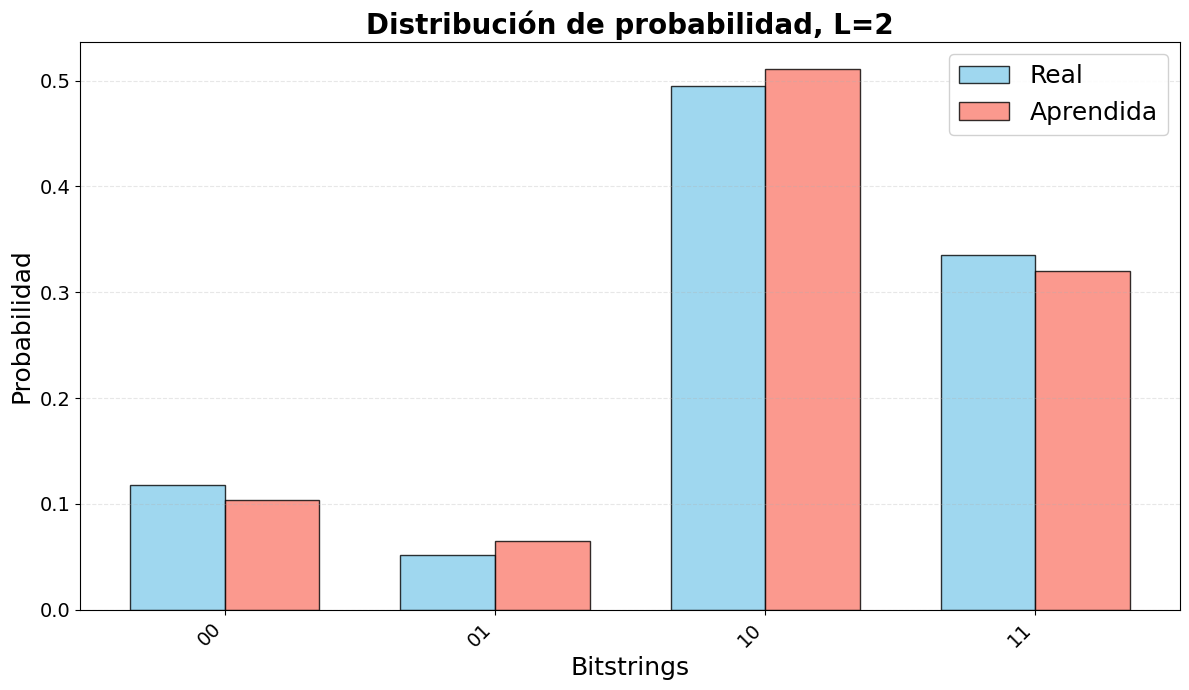

In [9]:
bar_plot_strings_comparison(bitstrings, normalized_counts, probs_np, CONFIG, CONFIG['L'])

### Training Loss

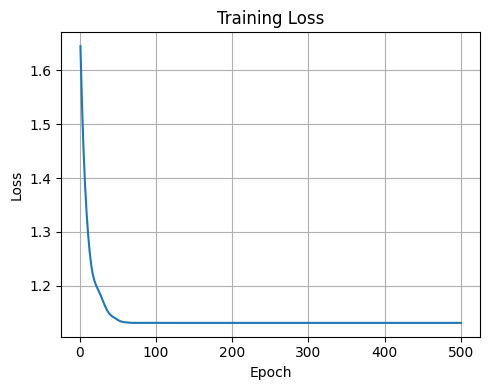

In [10]:
plot_training_loss(loss_history, CONFIG)